In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path("/content/drive/MyDrive/ML-Data")

#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.


#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

_

Z góry przepraszam za niedociągnięcia i jakieśbrakujące rzeczy, niestety termin wykładu w tym tygodniu mi nie pasował i musiałem go ominąć, mam nadzieję, że nie jest tragicznie :p

# Podsumowanie zadania 1

Poprzednie zadanie pokazało mi, że nie wszystkie dane są tak samo przydatne. Takie kolumny jak płeć, wiek czy klasa biletu miały największy wpływ na to, czy ktoś przeżył. Z kolei rzeczy typu imię czy numer biletu tylko zaśmiecałyby model, bo mają za dużo różnych, pojedynczych wartości, więc trzeba było je po prostu wywalić, żeby model mógł podejść do problemu bardziej ogółowo. Zauważyłem też, że algorytmy przyjmują tylko liczby, więc trzeba było zamienić tekst na zera i jedynki (One-Hot Encoding) i posprzątać puste komórki, bez tego żaden model by w ogóle nie ruszył.

Wiem, że sprawdzający zwrócił uwage na część danych którą usunąłem, ale zobaczyłem to trochę za późno więc sprawdzimy na ile te dane zmieniały później predykcję modeli w porównaniu do innych

# Pobranie danych z poprzedniego zadania

In [22]:
titanic_df = pd.read_csv(base_path / 'titanic_clean.csv', index_col='Unnamed: 0')

In [25]:
titanic_df.head(3)

,Survived,Pclass,FamilySize,Sex,Age,Fare,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Status
0,0,3,1,1,22.0,7.2500,0,0,1,0,0
1,1,1,1,0,38.0,71.2833,0,0,0,1,0
2,1,3,0,0,26.0,7.9250,0,1,0,0,0


# Przygotowanie danych pod uczenie modeli

Ok, skoro mamy nasze dane to przygotujmy cechy `x` i nasz cel `y`. Wiemy, że naszym celem będzie kolumna **survived** a cechami będzą pozostałe kolumny.

In [26]:
# X to nasze cechy (wszystko poza kolumną Survived)
cechy_X = titanic_df.drop('Survived', axis=1)

# y to nasz cel (tylko kolumna Survived)
cel_y = titanic_df['Survived']

Jeszcze zostaje podzielenie danych na testowe i treningowe. Do tego wykorzystamy funkcje sklearna `train_test_split`.

In [27]:
from sklearn.model_selection import train_test_split

# Dostaniemy 4 zbiory, 2 treningowe zwierające 80% danych oraz 2 testowe z 20%.
X_train, X_test, y_train, y_test = train_test_split(cechy_X, cel_y, test_size=0.2, random_state=42)

Ok, teraz zróbmy nasz baseline. Wykorzystamy do tego podany w zadaniu `DummyClassifier`.

In [28]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(cechy_X, cel_y)
dummy_clf.predict(cechy_X)
dummy_clf.score(cechy_X, cel_y)

0.6161616161616161

Wynik wyszedł nam koło 61.6%. Więc wyniki naszych przyszłych testów powinny wyjść większe od tych, osobiście celował bym w okolicę 80%.

# Metryki:

Funkcja `classification_report` zwraca 4 główne, daje to pełen obraz modelu. Nas głównie będą interesowały:
- Accuracy - ze względu na to, że nasz `DummyClassifier` zwraca nam właśnie tą metrykę więc będziemy mieć dobre porównanie
- F1-score - łączy ona pozostałe dwie recall i precision średnią harmoniczną, czyli przedstawia we wmiarę najlepszy sposób prawdziwą poprawność naszego modelu.

# Tworzenie i uczenie modeli:

Wybrałem dwa bazowe modele:
- Decision tree
- KNN

**Decision Tree**

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Tworzymy i "uczymy" model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# 2. Model "zgaduje" wyniki dla zbioru testowego
y_pred_tree = tree_model.predict(X_test)

# 3. Sprawdzamy wyniki
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Accuracy (Trening):", accuracy_score(y_train, tree_model.predict(X_train)))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred_tree))

Accuracy: 0.770949720670391
Accuracy (Trening): 0.9789325842696629

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80       105
           1       0.72      0.73      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



Drzewo decyzyjne wyciągnęło skuteczność na poziomie ~77% na zbiorze testowym, co jest sporym skokiem względem naszego baseline'u (61.6%). Widać jednak, że na zbiorze treningowym model ma skuteczność bliską 100%, co ewidentnie wskazuje na to, że drzewo za bardzo nauczyło się danych testowych (przetrenowanie). Z raportu widać też, że model trochę lepiej radzi sobie z wyłapywaniem ofiar (Recall 80%) niż osób, które przeżyły (Recall 73%).

**KNN**

In [68]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Tworzymy i uczymy model KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# 2. Model zgaduje wyniki dla zbioru testowego
y_pred_knn = knn_model.predict(X_test)

# 3. Sprawdzamy wyniki
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Accuracy (Trening):", accuracy_score(y_train, knn_model.predict(X_train)))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.7206703910614525
Accuracy (Trening): 0.7963483146067416

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.72      0.85      0.78       105
           1       0.71      0.54      0.62        74

    accuracy                           0.72       179
   macro avg       0.72      0.69      0.70       179
weighted avg       0.72      0.72      0.71       179



Możemy zobaczyć, że KNN poszedł nieco gorzej od Decision Tree. model KNN "zgaduje" na podstawie odległości między punktami, dla tego duże wartości takie jak `fare` czy `age`, więc jeszcze je wyskalowałem.

In [32]:
from sklearn.preprocessing import StandardScaler

# 1. Tworzymy obiekt skalera
scaler = StandardScaler()

# 2. "Uczymy" skaler na danych treningowych (fit) i od razu je przekształcamy (transform)
X_train_scaled = scaler.fit_transform(X_train)

# 3. Przekształcamy dane testowe, używając reguł nauczonych wyżej
X_test_scaled = scaler.transform(X_test)

Teraz podstawiamy wyskalowane dane do modelu.

In [72]:
# 1. Tworzymy i uczymy KNN na przeskalowanych danych
knn_model_scaled = KNeighborsClassifier()
knn_model_scaled.fit(X_train_scaled, y_train)

# 2. Zgadujemy dla przeskalowanego zbioru testowego
y_pred_knn_scaled = knn_model_scaled.predict(X_test_scaled)

# 3. Sprawdzamy wyniki
print("Accuracy:", accuracy_score(y_test, y_pred_knn_scaled))
print("Accuracy (Trening):", accuracy_score(y_train, knn_model_scaled.predict(X_train_scaled)))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred_knn_scaled))

Accuracy: 0.7877094972067039
Accuracy (Trening): 0.8637640449438202

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       105
           1       0.75      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



Zwykły model KNN na surowych danych poradził sobie słabiej (ok. 72%), bo algorytm gubił się przy dużych różnicach w liczbach. Dopiero po użyciu StandardScaler i wyrównaniu skali (np. wieku i opłaty za bilet), wynik na teście podskoczył do prawie 79%, co jest już super rezultatem. Tu również widać, że wynik na treningu jest wyższy, więc mamy pole przy optymalizacji hiperparametrów, żeby model podszedł do tego bardziej ogółowo.

# Badanie hiperparametrów

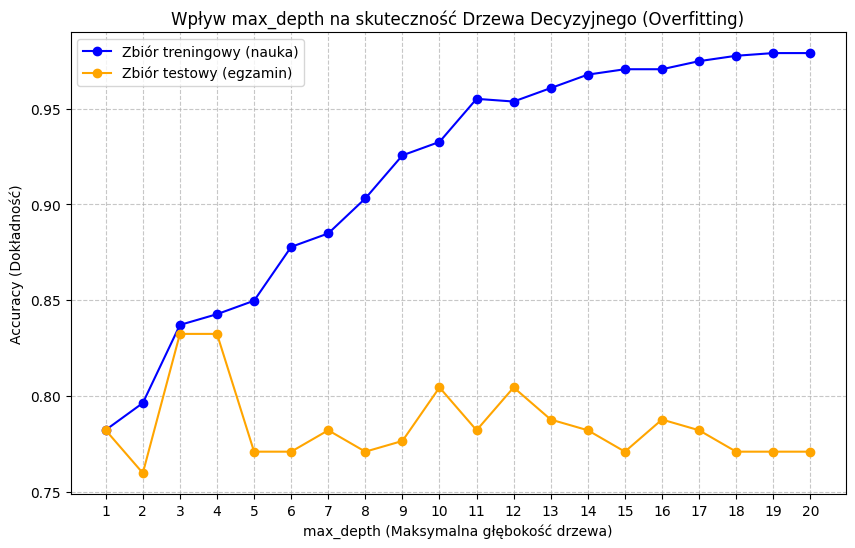

In [37]:
max_depths = range(1, 21)
train_scores = []
test_scores = []

# Pętla sprawdzająca każdą głębokość po kolei
for depth in max_depths:
    clf_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_tree.fit(X_train, y_train)

    # Zapisujemy Accuracy dla danych treningowych
    train_scores.append(accuracy_score(y_train, clf_tree.predict(X_train)))

    # Zapisujemy Accuracy dla danych testowych
    test_scores.append(accuracy_score(y_test, clf_tree.predict(X_test)))

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, label='Zbiór treningowy', marker='o', color='blue')
plt.plot(max_depths, test_scores, label='Zbiór testowy', marker='o', color='orange')

plt.title('Wpływ max_depth na skuteczność Drzewa Decyzyjnego')
plt.xlabel('max_depth (Maksymalna głębokość drzewa)')
plt.ylabel('Accuracy')
plt.xticks(max_depths)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Tu widzimy, że ze wzrostem maksymalnej głębokości rośnie nam skuteczność na zbiorze treningowym, lecz od pewnego momentu (w naszym wypadku 4) spada dla zbioru testowego. Tu właśnie dochodzi do przeuczenia, model uczy się dokładnie danych treningowych i gdy potem trafia na dane które nie są aż tak podobne do nich zaczyna popełniać błędy.

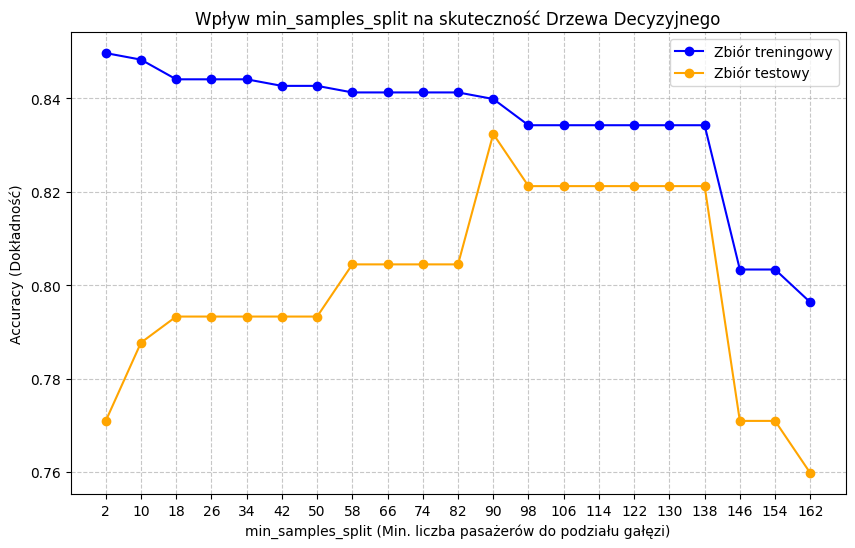

In [55]:
# Przygotowanie list na wyniki dla min_samples_split
min_samples = range(2, 163, 8)
train_scores_split = []
test_scores_split = []

# Pętla sprawdzająca
for samples in min_samples:
    # sprawdzamy na stałej wartości max_depth
    clf_tree = DecisionTreeClassifier(max_depth=5, min_samples_split=samples, random_state=42)
    clf_tree.fit(X_train, y_train)

    train_scores_split.append(accuracy_score(y_train, clf_tree.predict(X_train)))
    test_scores_split.append(accuracy_score(y_test, clf_tree.predict(X_test)))

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(min_samples, train_scores_split, label='Zbiór treningowy', marker='o', color='blue')
plt.plot(min_samples, test_scores_split, label='Zbiór testowy', marker='o', color='orange')

plt.title('Wpływ min_samples_split na skuteczność Drzewa Decyzyjnego')
plt.xlabel('min_samples_split (Min. liczba pasażerów do podziału gałęzi)')
plt.ylabel('Accuracy (Dokładność)')
plt.xticks(min_samples)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Zbyt mała liczba danych w gałęzi może doprowadzać do tego, że model będzie się uczył małych szczegółów zamiast podejść do zbioru danych bardziej ogółowo co może (co widać po wykresie) zmniejszać skuteczność modelu. Zwiększanie tej wartości pozwoli podejść bardziej ogółowo, z czym również nie można przesadzić bo model może przejść w drógą stronę i być zbyt ogółowy.

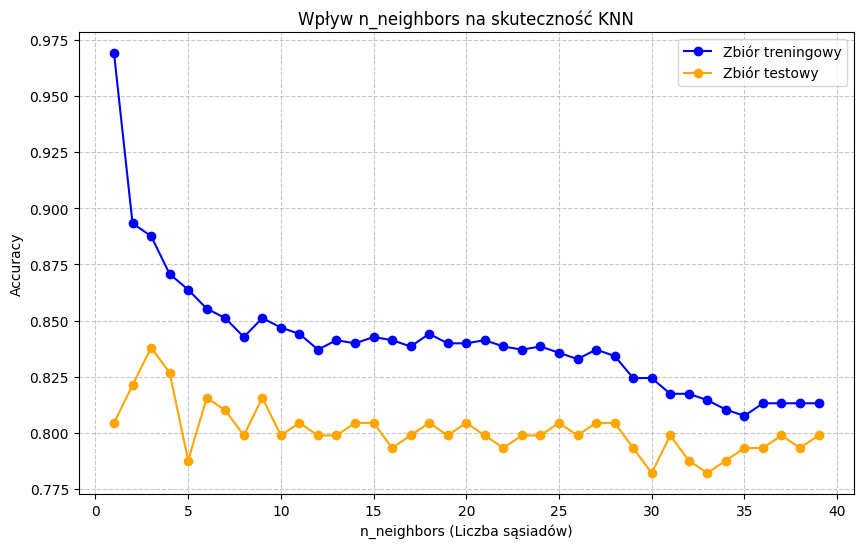

In [64]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Przygotowanie list na wyniki
neighbors_settings = range(1, 40)
train_scores_knn = []
test_scores_knn = []

# Pętla sprawdzająca liczbę sąsiadów
for n in neighbors_settings:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)

    # Zapisujemy wyniki
    train_scores_knn.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores_knn.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(neighbors_settings, train_scores_knn, label='Zbiór treningowy', marker='o', color='blue')
plt.plot(neighbors_settings, test_scores_knn, label='Zbiór testowy', marker='o', color='orange')

plt.title('Wpływ n_neighbors na skuteczność KNN')
plt.xlabel('n_neighbors (Liczba sąsiadów)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Zbyt mała liczba sąsiadów sprawia, że model za bardzo ufa pojedynczym osobom i uczy się przypadkowych szczegółów, co (jak widać na wykresie) daje fałszywie idealny wynik na treningu, ale słaby na nowych danych. Zwiększanie tej wartości pozwala modelowi podejść do problemu bardziej ogółowo, z czym również nie można przesadzić, bo przy zbyt dużej liczbie sąsiadów algorytm przechodzi w drugą stronę i staje się po prostu za bardzo uogólniony.

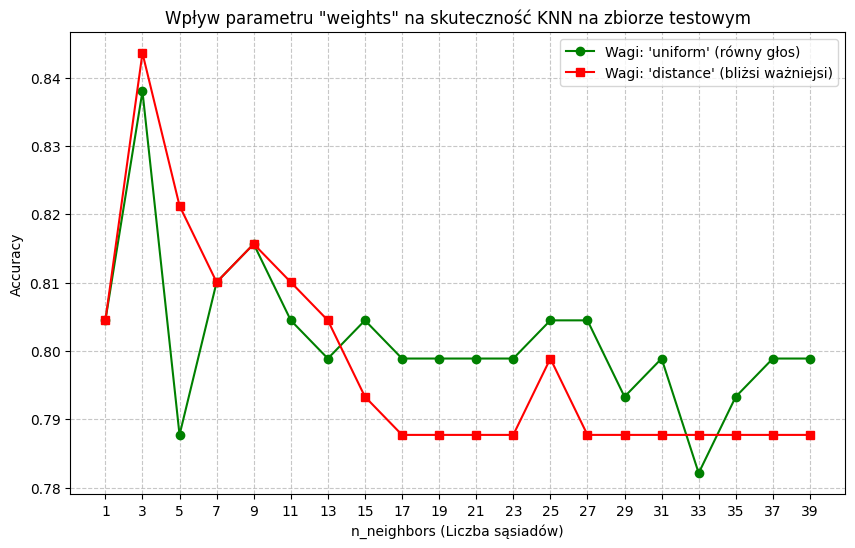

In [65]:
# Przygotowanie list na wyniki dla zbioru testowego
neighbors_settings = range(1, 40, 2)
test_scores_uniform = []
test_scores_distance = []

# Pętla sprawdzająca oba ustawienia
for n in neighbors_settings:
    # Model 1: uniform
    knn_uni = KNeighborsClassifier(n_neighbors=n, weights='uniform')
    knn_uni.fit(X_train_scaled, y_train)
    test_scores_uniform.append(accuracy_score(y_test, knn_uni.predict(X_test_scaled)))

    # Model 2: distance
    knn_dist = KNeighborsClassifier(n_neighbors=n, weights='distance')
    knn_dist.fit(X_train_scaled, y_train)
    test_scores_distance.append(accuracy_score(y_test, knn_dist.predict(X_test_scaled)))

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(neighbors_settings, test_scores_uniform, label="Wagi: 'uniform' (równy głos)", marker='o', color='green')
plt.plot(neighbors_settings, test_scores_distance, label="Wagi: 'distance' (bliżsi ważniejsi)", marker='s', color='red')

plt.title('Wpływ parametru "weights" na skuteczność KNN na zbiorze testowym')
plt.xlabel('n_neighbors (Liczba sąsiadów)')
plt.ylabel('Accuracy')
plt.xticks(neighbors_settings)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Nadanie większej wagi tylko tym najbliższym sąsiadom (wagi 'distance') sprawdza się fajnie przy małych grupach, ale przy zbyt dużej liczbie sąsiadów model ewidentnie zaczyna się gubić i jego skuteczność spada. Z kolei równe traktowanie głosu wszystkich (wagi 'uniform') pozwala modelowi działać dużo stabilniej i sensowniej przy większych grupach, co ładnie widać po zielonej linii, która z czasem utrzymuje się wyżej.

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. GridSearchCV dla Drzewa Decyzyjnego
tree_params = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20, 30]
}
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), tree_params, cv=5, scoring='accuracy')
tree_grid.fit(X_train, y_train)

print("Najlepsze parametry (Drzewo):", tree_grid.best_params_)
print("Najlepszy wynik walidacji (Drzewo):", round(tree_grid.best_score_, 4))

# 2. GridSearchCV dla KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'], # uniform - wszyscy sąsiedzi ważni tak samo, distance - bliżsi sąsiedzi ważniejsi
    'metric': ['euclidean', 'manhattan'] # sposób mierzenia odległości
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train) # Używamy ustandaryzowanych danych!

print("\nNajlepsze parametry (KNN):", knn_grid.best_params_)
print("Najlepszy wynik walidacji (KNN):", round(knn_grid.best_score_, 4))

--- SZUKANIE OPTYMALNYCH PARAMETRÓW ---

Najlepsze parametry (Drzewo): {'max_depth': 7, 'min_samples_split': 5}
Najlepszy wynik walidacji (Drzewo): 0.8216

Najlepsze parametry (KNN): {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Najlepszy wynik walidacji (KNN): 0.8342


Funkcja `GridSearchCV` sprawdza listę parametrów którą mu podamy i na jej podstawie wybiera najbardziej optymalne hiperparametry. Po wynikach możemy zobaczyć, że wyniki niekoniecznie zgadzają się z wynikami z wykresów. Dzieje się tak najprawdopodobniej z tego powodu, że nasze dane z wykresów biorą się z jednego podziału który mógł akórat wypaść tak. A `GridSearchCV` sprawdza te dane tzw. Kroswalidacją która dzieli nasz zbiór kilka razy i bada je jako zbiory i testowe i treningowe.

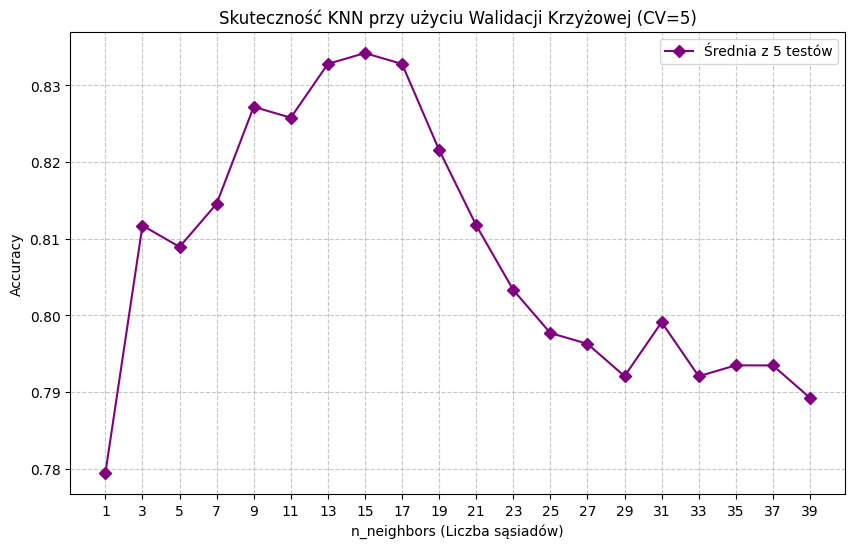

In [66]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = []
neighbors_settings = range(1, 40, 2)

for n in neighbors_settings:
    knn_cv = KNeighborsClassifier(n_neighbors=n, weights='uniform')
    # cross_val_score automatycznie dzieli zbiór na 5 części, uczy i testuje
    scores = cross_val_score(knn_cv, X_train_scaled, y_train, cv=5, scoring='accuracy')
    # Zapisujemy średnią z tych 5 prób
    cv_scores.append(np.mean(scores))

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(neighbors_settings, cv_scores, label='Średnia z 5 testów', marker='D', color='purple')

plt.title('Skuteczność KNN przy użyciu Walidacji Krzyżowej (CV=5)')
plt.xlabel('n_neighbors (Liczba sąsiadów)')
plt.ylabel('Accuracy')
plt.xticks(neighbors_settings)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Tu przykład badania n_neighbors z użyciem kroswalidacji. Tu już możemy zobaczyć, że wyniki się zgadzają.

# Podsumowanie i wnioski

**Podsumowanie**

W tym zadaniu przygotowałem dwa modele ML (KNN i DecisionTree), oba pracowały na danych przygotowanych w zeszłotygodniowym zadaniu. Obydwa modele porównałem z baseline (`DummyClassifier`), oba modele wykazały wyraźny wzrost w poprawności głosowania. Model KNN opiera się na odległościach więc dla poprawy wyników zunifikowałem wartości co przyniosło poprawę. Na sam koniec dokonałem analizy działań modeli w zależności od hiperparametrów.

**Wnioski**

Ważne jest aby dobrze nauczyć model, nie powinniśmy skupiać się na prawie 100% wyuczeniem modelu treningowego, ponieważ gdy potem przejdziemy na inne zbiory danych model będzie mniej skuteczny przez przetrenowanie. Możemy to usprawnic używając jak najbardziej optymalnych hiperparametrów (których znalezienie ułatwi nam `GridSearchCV`) oraz stosowanie tzw. kroswalidacji która dzieli nam zbiór na kilka a następnie testuje każdy jako testowy i pozostałe jako treningowe. Ważne jest również poprawne przygotowanie danych ponieważ większość algorytmów kożysta z wartości liczbowych (np. jak KNN miało by obliczyć odległość po znakach?).